# 05 — Persona Classifier

Train an **XGBoost classifier** that maps customer behavioral features → Persona label.

This enables real-time persona prediction for new customers from their transaction history.

Steps:
1. Load clustered features + map cluster IDs to persona names
2. Train/test split (80/20 stratified)
3. XGBoost with GridSearchCV tuning
4. Evaluate: classification report + confusion matrix
5. SHAP feature importance — understand which features drive each persona
6. Demonstrate inference on a new customer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, pathlib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (12, 5)

# Load data
features = pd.read_parquet('data/processed/customer_features_clustered.parquet')

with open('outputs/personas.json') as f:
    personas_data = json.load(f)

# Map cluster int → persona name
cluster_to_persona = {
    int(cid): data['persona'].get('name', f'Cluster {cid}')
    for cid, data in personas_data.items()
}
print('Cluster → Persona mapping:')
for k, v in sorted(cluster_to_persona.items()):
    print(f'  {k}: {v}')

Cluster → Persona mapping:
  0: Dormant Dabblers
  1: Hyperactive Omnivores
  2: Steady Commuter Mainstays
  3: Rare Big-Ticket Splurgers


## 1. Prepare Features and Labels

In [2]:
feature_cols = [c for c in features.columns if c != 'cluster']

X = features[feature_cols].copy()
y_raw = features['cluster'].map(cluster_to_persona)

# Encode persona names to integers for XGBoost
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

print(f'Features : {X.shape[1]}')
print(f'Customers: {len(X)}')
print(f'Classes  : {list(class_names)}')
print(f'Class distribution:\n{y_raw.value_counts()}')

Features : 108
Customers: 948
Classes  : ['Dormant Dabblers', 'Hyperactive Omnivores', 'Rare Big-Ticket Splurgers', 'Steady Commuter Mainstays']
Class distribution:
cluster
Steady Commuter Mainstays    361
Hyperactive Omnivores        326
Dormant Dabblers             239
Rare Big-Ticket Splurgers     22
Name: count, dtype: int64


In [3]:
# Log-transform skewed features (same as in clustering notebook)
LOG_COLS = ['avg_txn_amt', 'median_txn_amt', 'std_txn_amt', 'max_txn_amt',
            'total_spend', 'total_txn_count', 'n_unique_merchants', 'avg_days_between_txn']
for col in LOG_COLS:
    if col in X.columns:
        X[col] = np.log1p(X[col])

# Train / test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 758  |  Test: 190


## 2. Train XGBoost Classifier

In [4]:
# Quick GridSearchCV over key hyperparameters
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0],
}

base_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    base_model, param_grid,
    cv=cv, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest params  : {grid_search.best_params_}')
print(f'Best CV F1   : {grid_search.best_score_:.4f}')

model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/tzu-chunchen/Documents/AI/AI_Personalization/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:24:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tzu-chunchen/Documents/AI/AI_Personalization/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:24:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tzu-chunchen/Documents/AI/AI_Personalization/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:24:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/tzu-chunchen/Documents/AI/AI_Personalization/.venv/lib/python3.13/site-packages/xgboost/training.py:200: 


Best params  : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Best CV F1   : 0.9841


## 3. Evaluate on Test Set

In [5]:
y_pred = model.predict(X_test)
y_pred_names = le.inverse_transform(y_pred)
y_test_names = le.inverse_transform(y_test)

print('=== Classification Report ===')
print(classification_report(y_test_names, y_pred_names))

=== Classification Report ===
                           precision    recall  f1-score   support

         Dormant Dabblers       1.00      1.00      1.00        48
    Hyperactive Omnivores       0.98      0.97      0.98        65
Rare Big-Ticket Splurgers       1.00      1.00      1.00         5
Steady Commuter Mainstays       0.97      0.99      0.98        72

                 accuracy                           0.98       190
                macro avg       0.99      0.99      0.99       190
             weighted avg       0.98      0.98      0.98       190



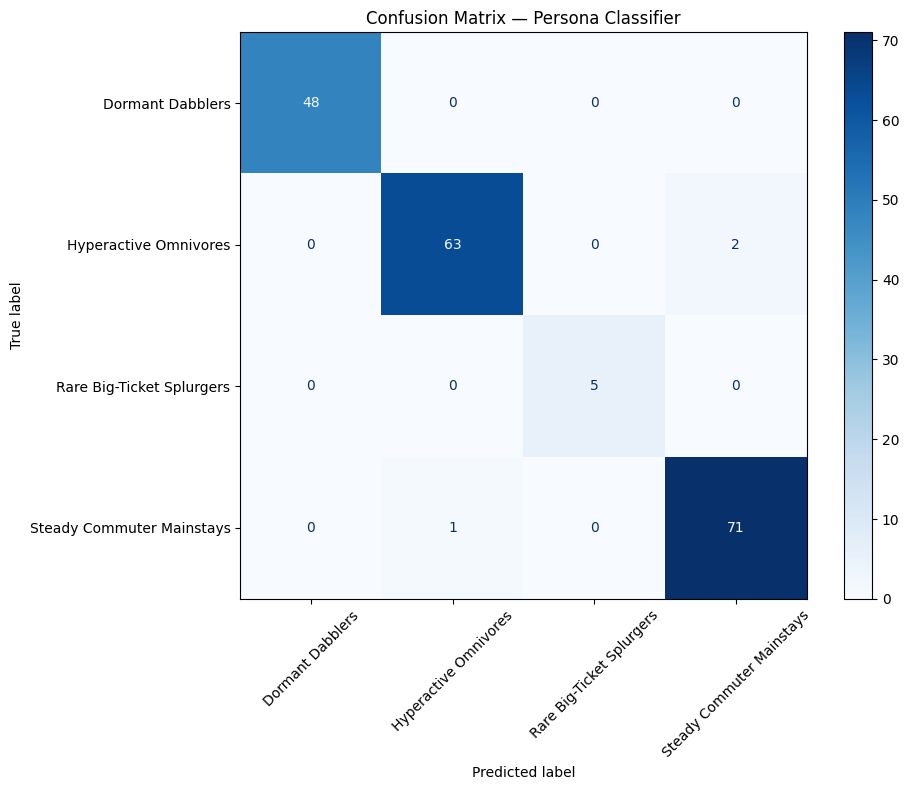

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test_names, y_pred_names, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix — Persona Classifier')
plt.tight_layout()
plt.savefig('outputs/cluster_plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. XGBoost Feature Importance

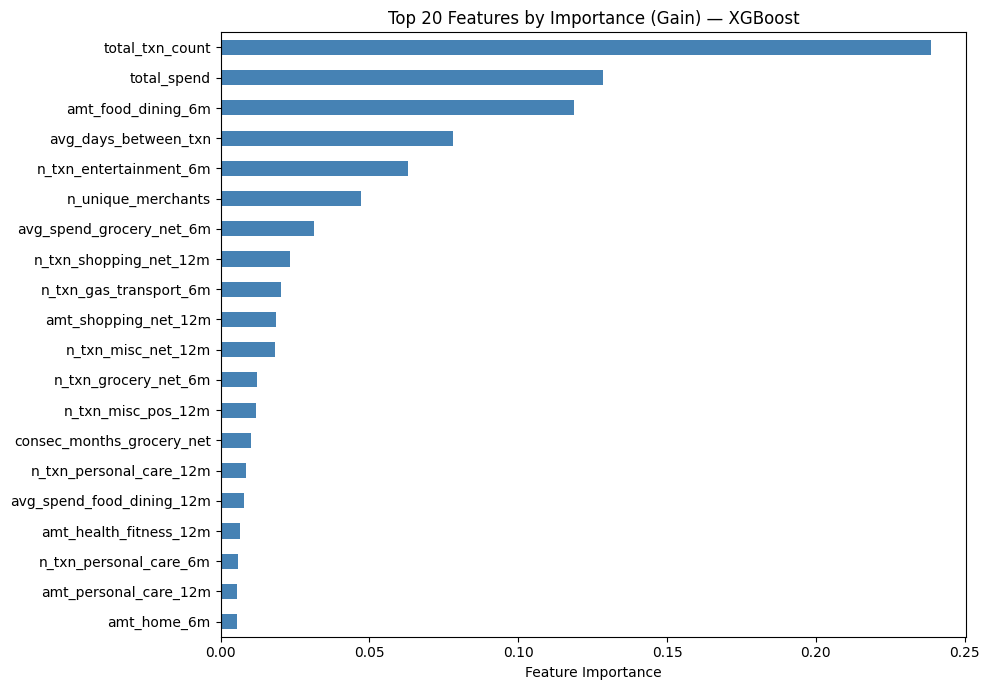

In [7]:
# Built-in feature importance (gain)
importance = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importance.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Features by Importance (Gain) — XGBoost')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('outputs/cluster_plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Analysis — Why Each Prediction?

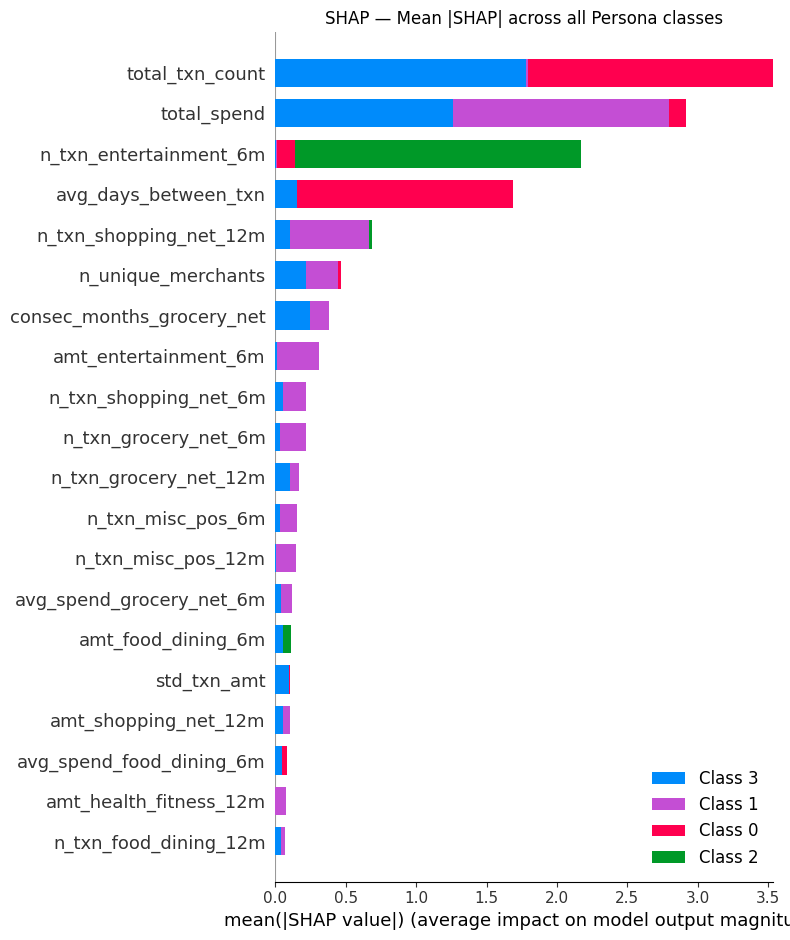

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot (all classes)
plt.figure()
shap.summary_plot(
    shap_values if not isinstance(shap_values, list) else np.abs(np.array(shap_values)).mean(axis=0),
    X_test,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Mean |SHAP| across all Persona classes')
plt.tight_layout()
plt.savefig('outputs/cluster_plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Per-class SHAP beeswarm for class 0
if isinstance(shap_values, list) and len(shap_values) > 0:
    for i, name in enumerate(class_names):
        plt.figure()
        shap.summary_plot(shap_values[i], X_test, feature_names=feature_cols,
                          max_display=15, show=False)
        plt.title(f'SHAP — Class: {name}')
        plt.tight_layout()
        safe_name = name.replace(' ', '_').replace('/', '_')
        plt.savefig(f'outputs/cluster_plots/shap_{safe_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 6. LLM Cluster Explanations

For each persona, ask Claude to explain **why** this cluster received its name by combining:
- **Statistical evidence** — which metrics are significantly above / below the dataset average
- **Algorithm insight** — what the chosen clustering algorithm (hierarchical or K-Means) reveals
  about this group's cohesion, structure, and boundaries
- **Classifier insight** — the top SHAP features the XGBoost model learned to identify this persona

Output saved to `outputs/cluster_explanations.json`.

In [ ]:
import anthropic, yaml

# ── Load config ───────────────────────────────────────────────────────────────
with open('config.yaml') as f:
    _cfg = yaml.safe_load(f)

CLUSTERING_ALGORITHM = str(_cfg.get('clustering_algorithm', 'hierarchical')).lower()
PERSONA_TONE         = str(_cfg.get('persona_tone', 'easy')).lower()

TONE_INSTRUCTIONS = {
    'easy':
        'Use plain, everyday language. Avoid jargon. Use simple analogies a '
        'non-technical person would immediately understand.',
    'professional':
        'Use formal business language. Frame insights as actionable recommendations '
        'suitable for executive presentations.',
    'data-driven':
        'Emphasise specific numbers and statistical ratios throughout. Quantify '
        'everything you can. Use technical language and cite exact metric values.',
    'creative':
        'Use vivid metaphors, storytelling, and imaginative analogies. Make each '
        'persona feel like a character with a distinct story.',
}.get(PERSONA_TONE, 'Use plain, everyday language. Avoid jargon.')

# Algorithm-specific context for the LLM
ALGO_CONTEXT = {
    'kmeans': (
        'K-Means clustering assigns each customer to the nearest centroid in the '
        'scaled feature space. The centroid represents the "average member" of the cluster. '
        'A tight cluster (high silhouette) means customers are geometrically close — '
        'very similar across all behavioral features. When explaining, reference what '
        'the centroid position tells us: the centroid of this cluster sits far from '
        'others along specific feature axes, which is why those features are the '
        'dominant identifiers.'
    ),
    'hierarchical': (
        'Agglomerative Hierarchical Clustering (Ward linkage) builds a dendrogram by '
        'iteratively merging the most similar customers. Ward linkage minimises total '
        'within-cluster variance at each merge step, making it sensitive to tight '
        'behavioural sub-groups. Customers in the same cluster were consistently grouped '
        'together before being merged with other groups — a sign of strong cohesion. '
        'When explaining, note what the dendrogram structure implies: tight sub-branches '
        'suggest potential sub-segments (e.g. a traveller cluster may branch into '
        '"nearby-country travellers" vs "cross-continent travellers").'
    ),
}.get(CLUSTERING_ALGORITHM,
    'Clustering grouped customers by minimising within-group distance in the feature space.')

print(f'Algorithm : {CLUSTERING_ALGORITHM}')
print(f'Tone      : {PERSONA_TONE}')

In [ ]:
# ── Extract top SHAP features per class ──────────────────────────────────────
# Maps each persona name → top discriminating features ranked by mean |SHAP|

persona_to_cluster = {v: k for k, v in cluster_to_persona.items()}
class_top_shap = {}

sv_array = np.array(shap_values)   # works whether shap_values is list or ndarray

if sv_array.ndim == 3:
    # Possible shapes: (n_classes, n_samples, n_features) or (n_samples, n_features, n_classes)
    if sv_array.shape[0] == len(class_names):
        # (n_classes, n_samples, n_features)
        for i, cls in enumerate(class_names):
            mean_abs = np.abs(sv_array[i]).mean(axis=0)
            top_idx  = np.argsort(-mean_abs)[:12]
            class_top_shap[cls] = [
                {'feature': feature_cols[j], 'mean_abs_shap': round(float(mean_abs[j]), 4)}
                for j in top_idx
            ]
    else:
        # (n_samples, n_features, n_classes)
        for i, cls in enumerate(class_names):
            mean_abs = np.abs(sv_array[:, :, i]).mean(axis=0)
            top_idx  = np.argsort(-mean_abs)[:12]
            class_top_shap[cls] = [
                {'feature': feature_cols[j], 'mean_abs_shap': round(float(mean_abs[j]), 4)}
                for j in top_idx
            ]
elif sv_array.ndim == 2:
    # Aggregate only — use the same top features for every class
    mean_abs = np.abs(sv_array).mean(axis=0)
    top_idx  = np.argsort(-mean_abs)[:12]
    top_feats = [
        {'feature': feature_cols[j], 'mean_abs_shap': round(float(mean_abs[j]), 4)}
        for j in top_idx
    ]
    for cls in class_names:
        class_top_shap[cls] = top_feats
else:
    print('SHAP values format not recognised — skipping per-class SHAP enrichment.')

print('Top 5 SHAP features per class:')
for cls, feats in class_top_shap.items():
    print(f'  {cls}: {[f["feature"] for f in feats[:5]]}')

In [ ]:
def build_explanation_prompt(
    personas_data: dict,
    class_top_shap: dict,
    algo_context: str,
    clustering_algorithm: str,
    tone_instructions: str,
) -> str:
    """
    Build a prompt asking Claude to explain WHY each cluster was named as it was.
    Evidence comes from three sources:
      1. Statistical metrics (above/below-average categories)
      2. Clustering algorithm insight (cohesion, potential sub-segments)
      3. XGBoost SHAP importance (what the classifier learned to recognise)
    """
    cluster_blocks = []

    for cid, data in personas_data.items():
        persona      = data['persona']
        stats        = data['cluster_stats']
        persona_name = persona.get('name', f'Cluster {cid}')
        tagline      = persona.get('tagline', '')
        cat_stats    = stats['category_stats']
        overall      = stats['overall']
        algo_detail  = stats.get('algorithm_detail', clustering_algorithm)

        # Separate clearly above- and below-average categories
        above_avg = [(cat, s) for cat, s in cat_stats.items() if s['rel_n_txn'] >= 1.2]
        below_avg = [(cat, s) for cat, s in cat_stats.items() if s['rel_n_txn'] <= 0.7]
        above_avg.sort(key=lambda x: -x[1]['rel_n_txn'])
        below_avg.sort(key=lambda x:  x[1]['rel_n_txn'])

        above_lines = '\n'.join(
            f"    + {cat:<20}  vs_avg={s['rel_n_txn']}x  "
            f"txns/yr={s['n_txn_12m']}  avg/txn=${s['avg_spend_12m']}  "
            f"consec={s['consec_months']} months  spend/yr=${s['total_amt_12m']}"
            for cat, s in above_avg[:7]
        ) or '    (none significantly above average)'

        below_lines = '\n'.join(
            f"    - {cat:<20}  vs_avg={s['rel_n_txn']}x  "
            f"txns/yr={s['n_txn_12m']}  avg/txn=${s['avg_spend_12m']}"
            for cat, s in below_avg[:7]
        ) or '    (none significantly below average)'

        # Top SHAP features for this persona
        shap_block = ''
        if persona_name in class_top_shap:
            shap_lines = '\n'.join(
                f"    {i+1:2}. {f['feature']:<35} SHAP={f['mean_abs_shap']}"
                for i, f in enumerate(class_top_shap[persona_name][:10])
            )
            shap_block = (
                f"\n  XGBoost top discriminating features (mean |SHAP| on test set):\n"
                f"{shap_lines}"
            )

        cluster_blocks.append(
            f"\n{'='*65}\n"
            f"CLUSTER {cid}: \"{persona_name}\"\n"
            f"Tagline   : {tagline}\n"
            f"Algorithm : {algo_detail}\n"
            f"Size      : {stats['n_customers']} customers\n"
            f"\nABOVE-AVERAGE categories (vs_avg >= 1.2x):\n{above_lines}\n"
            f"\nBELOW-AVERAGE categories (vs_avg <= 0.7x):\n{below_lines}\n"
            f"\nOverall metrics:\n"
            f"  avg_txn_amt         = ${overall['avg_txn_amt']}\n"
            f"  total_spend/yr      = ${overall['total_spend']}\n"
            f"  txns_per_yr         = {overall['total_txn_count']}\n"
            f"  pct_high_value      = {overall['pct_high_value']}%\n"
            f"  avg_days_between    = {overall['avg_days_between_txn']} days\n"
            f"  n_unique_categories = {overall['n_unique_categories']}\n"
            f"  active_months       = {overall['active_months']}"
            f"{shap_block}"
        )

    all_blocks = '\n'.join(cluster_blocks)
    n_clusters = len(personas_data)

    return f"""You are a data science analyst explaining machine learning clustering results to a business and technical audience.

CLUSTERING ALGORITHM CONTEXT:
{algo_context}

{all_blocks}

{'='*65}

For EACH of the {n_clusters} clusters above, write a detailed explanation of WHY it was named as it is.

Your explanation must cover all four of these areas:

1. BEHAVIORAL EVIDENCE — Lead with the 2-4 strongest signals. State specific numbers:
   e.g. "This group makes travel transactions at 3.2x the average rate, with an average
   spend of $420 per transaction and 8 consecutive months of travel activity."

2. CONTRAST — What is this cluster notably WEAK at? Name specific categories with values.
   This contrast is what makes the persona distinct from others.

3. ALGORITHM INSIGHT — What does the {clustering_algorithm} algorithm tell us about this
   cluster's cohesion? For hierarchical: are these customers tightly linked (merged early
   in the dendrogram) or loosely linked? Does the Ward linkage suggest tight sub-branches
   that could represent sub-segments? For K-Means: how far is this centroid from others,
   and what axes separate it most?

4. CLASSIFIER INSIGHT — The XGBoost SHAP values show which features the model learned to
   use to identify this persona. Explain why those top SHAP features make sense given what
   the cluster looks like behaviorally.

Also suggest 1-3 potential sub-segments within this cluster (e.g. "travellers could split
into regional travellers vs. cross-continent travellers based on spending at foreign-country
merchants and transaction frequency").

TONE REQUIREMENT: {tone_instructions}

Return ONLY a valid JSON object (no markdown, no extra text) with this exact structure:
{{
  "0": {{
    "persona_name": "...",
    "explanation": "Full narrative explanation covering all 4 areas above (3-5 paragraphs)",
    "key_high_metrics": [
      {{"metric": "travel vs_avg", "value": "3.2x average", "interpretation": "Makes 3x more travel transactions than a typical customer"}},
      ...
    ],
    "key_low_metrics": [
      {{"metric": "food_dining vs_avg", "value": "0.3x average", "interpretation": "Rarely eats out or uses the card for food"}},
      ...
    ],
    "algorithm_insight": "One paragraph on what {clustering_algorithm} reveals about cohesion and boundaries",
    "classifier_insight": "One paragraph on why the top SHAP features make sense for identifying this persona",
    "potential_sub_segments": [
      "Sub-segment description 1",
      "Sub-segment description 2"
    ]
  }},
  "1": {{ ... }},
  ...
}}"""


# ── Call Claude ───────────────────────────────────────────────────────────────
_expl_client = anthropic.Anthropic()

print(f'Building explanation prompt for {len(personas_data)} clusters...')
expl_prompt = build_explanation_prompt(
    personas_data, class_top_shap, ALGO_CONTEXT,
    CLUSTERING_ALGORITHM, TONE_INSTRUCTIONS
)

print(f'Calling Claude (max_tokens=8192)...')
_expl_response = _expl_client.messages.create(
    model='claude-sonnet-4-6',
    max_tokens=8192,
    messages=[{'role': 'user', 'content': expl_prompt}]
)

raw_expl = _expl_response.content[0].text.strip()

# Strip markdown fences if present
if '```' in raw_expl:
    for part in raw_expl.split('```'):
        p = part.strip()
        if p.startswith('json'): p = p[4:].strip()
        if p.startswith('{'): raw_expl = p; break

try:
    cluster_explanations = json.loads(raw_expl)
    print(f'Parsed successfully — {len(cluster_explanations)} cluster explanations.\n')
    for cid, expl in cluster_explanations.items():
        print(f'  Cluster {cid}: "{expl.get("persona_name", "?")}" — explanation generated')
except json.JSONDecodeError as e:
    print(f'JSON parse error: {e}')
    print('Raw (first 600 chars):', raw_expl[:600])
    cluster_explanations = {}

# Save
with open('outputs/cluster_explanations.json', 'w') as f:
    json.dump(cluster_explanations, f, indent=2)
print('\nSaved outputs/cluster_explanations.json')

In [ ]:
# ── Pretty-print cluster explanations ────────────────────────────────────────
SEP = '=' * 70

print(f'\n{SEP}')
print('CLUSTER EXPLANATIONS — WHY EACH PERSONA WAS NAMED AS IT IS')
print(f'{SEP}')

for cid, expl in cluster_explanations.items():
    name = expl.get('persona_name', f'Cluster {cid}')
    print(f'\n{"─"*70}')
    print(f'CLUSTER {cid}: {name}')
    print('─' * 70)

    print('\nEXPLANATION:')
    print(expl.get('explanation', 'N/A'))

    print('\nABOVE-AVERAGE METRICS:')
    for m in expl.get('key_high_metrics', []):
        print(f'  + {m["metric"]:<35} {m["value"]}')
        print(f'    → {m["interpretation"]}')

    print('\nBELOW-AVERAGE METRICS:')
    for m in expl.get('key_low_metrics', []):
        print(f'  - {m["metric"]:<35} {m["value"]}')
        print(f'    → {m["interpretation"]}')

    print('\nALGORITHM INSIGHT:')
    print(expl.get('algorithm_insight', 'N/A'))

    print('\nCLASSIFIER INSIGHT (XGBoost / SHAP):')
    print(expl.get('classifier_insight', 'N/A'))

    sub_segs = expl.get('potential_sub_segments', [])
    if sub_segs:
        print('\nPOTENTIAL SUB-SEGMENTS:')
        for s in sub_segs:
            print(f'  • {s}')

print(f'\n{SEP}')

## 7. Inference Demo — Predict Persona for a New Customer

In [10]:
def predict_persona(transaction_df: pd.DataFrame) -> dict:
    """
    Given a DataFrame of raw transactions for ONE new customer,
    compute features and predict their persona.

    transaction_df must have columns:
      trans_date_trans_time (datetime), merchant (str), category (str), amt (float)
    """
    from dateutil.relativedelta import relativedelta

    df = transaction_df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    if 'merchant' in df.columns:
        df['merchant'] = df['merchant'].astype(str).str.replace('^fraud_', '', regex=True)
    df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')

    CATEGORIES = [
        'entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos',
        'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos',
        'personal_care', 'shopping_net', 'shopping_pos', 'travel'
    ]
    WINDOWS = [6, 12]
    ref_date = df['trans_date_trans_time'].max()

    def _max_consecutive_months(month_periods):
        if len(month_periods) == 0:
            return 0
        sorted_months = sorted(set(month_periods))
        max_streak, streak = 1, 1
        for i in range(1, len(sorted_months)):
            diff = (sorted_months[i] - sorted_months[i - 1]).n
            if diff == 1:
                streak += 1
                max_streak = max(max_streak, streak)
            else:
                streak = 1
        return max_streak

    row = {c: 0.0 for c in feature_cols}

    for w in WINDOWS:
        cutoff = ref_date - relativedelta(months=w)
        df_w = df[df['trans_date_trans_time'] > cutoff]
        for cat in CATEGORIES:
            df_cat = df_w[df_w['category'] == cat]
            n, s = len(df_cat), df_cat['amt'].sum()
            row[f'n_txn_{cat}_{w}m'] = n
            row[f'amt_{cat}_{w}m'] = s
            row[f'avg_spend_{cat}_{w}m'] = s / n if n > 0 else 0.0

    for cat in CATEGORIES:
        df_cat = df[df['category'] == cat]
        row[f'consec_months_{cat}'] = _max_consecutive_months(df_cat['year_month'].tolist())

    total_txn = len(df)
    total_spend = df['amt'].sum()
    dates = df['trans_date_trans_time'].sort_values()
    row['total_txn_count'] = total_txn
    row['total_spend'] = total_spend
    row['avg_txn_amt'] = df['amt'].mean()
    row['std_txn_amt'] = float(df['amt'].std()) if total_txn > 1 else 0.0
    row['max_txn_amt'] = df['amt'].max()
    row['pct_high_value'] = (df['amt'] > 200).mean()
    row['n_unique_categories'] = df['category'].nunique()
    row['n_unique_merchants'] = df['merchant'].nunique() if 'merchant' in df.columns else 0
    row['active_months'] = df['year_month'].nunique()
    row['avg_days_between_txn'] = float(dates.diff().dropna().dt.days.mean()) if len(dates) > 1 else 0.0

    feat_df = pd.DataFrame([row])[feature_cols]

    # Log-transform
    for col in LOG_COLS:
        if col in feat_df.columns:
            feat_df[col] = np.log1p(feat_df[col])

    pred_enc  = model.predict(feat_df)[0]
    pred_name = le.inverse_transform([pred_enc])[0]
    proba     = model.predict_proba(feat_df)[0]
    confidence = proba.max()

    return {
        'predicted_persona' : pred_name,
        'confidence'        : round(float(confidence), 3),
        'all_probabilities' : {le.classes_[i]: round(float(p),3) for i,p in enumerate(proba)}
    }


# --- Demo: take a real customer from the test CSV and predict ---
import pandas as pd

raw = pd.read_csv('data/raw/fraudTest.csv', index_col=0, parse_dates=['trans_date_trans_time'])

# Pick the first customer in the test set
sample_customer = raw['cc_num'].iloc[0]
sample_txns = raw[raw['cc_num'] == sample_customer].copy()
print(f'Sample customer {sample_customer}: {len(sample_txns)} transactions')

result = predict_persona(sample_txns)
print(f'\nPredicted Persona : {result["predicted_persona"]}')
print(f'Confidence        : {result["confidence"]*100:.1f}%')
print(f'All probabilities :')
for persona, prob in sorted(result['all_probabilities'].items(), key=lambda x: -x[1]):
    bar = '█' * int(prob * 20)
    print(f'  {persona:<35} {prob*100:5.1f}%  {bar}')

Sample customer 2291163933867244: 640 transactions


KeyError: "['n_txn_entertainment_6m', 'amt_entertainment_6m', 'avg_spend_entertainment_6m', 'n_txn_food_dining_6m', 'amt_food_dining_6m', 'avg_spend_food_dining_6m', 'n_txn_gas_transport_6m', 'amt_gas_transport_6m', 'avg_spend_gas_transport_6m', 'n_txn_grocery_net_6m', 'amt_grocery_net_6m', 'avg_spend_grocery_net_6m', 'n_txn_grocery_pos_6m', 'amt_grocery_pos_6m', 'avg_spend_grocery_pos_6m', 'n_txn_health_fitness_6m', 'amt_health_fitness_6m', 'avg_spend_health_fitness_6m', 'n_txn_home_6m', 'amt_home_6m', 'avg_spend_home_6m', 'n_txn_kids_pets_6m', 'amt_kids_pets_6m', 'avg_spend_kids_pets_6m', 'n_txn_misc_net_6m', 'amt_misc_net_6m', 'avg_spend_misc_net_6m', 'n_txn_misc_pos_6m', 'amt_misc_pos_6m', 'avg_spend_misc_pos_6m', 'n_txn_personal_care_6m', 'amt_personal_care_6m', 'avg_spend_personal_care_6m', 'n_txn_shopping_net_6m', 'amt_shopping_net_6m', 'avg_spend_shopping_net_6m', 'n_txn_shopping_pos_6m', 'amt_shopping_pos_6m', 'avg_spend_shopping_pos_6m', 'n_txn_travel_6m', 'amt_travel_6m', 'a